In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/weather-type-classification/weather_classification_data.csv


In [2]:
df = pd.read_csv('/kaggle/input/weather-type-classification/weather_classification_data.csv')
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy


# Data Wrangling

In this Section I will Check for missing values in Data, Duplicates etc. and remove them

In [3]:
import seaborn as sns

<Axes: >

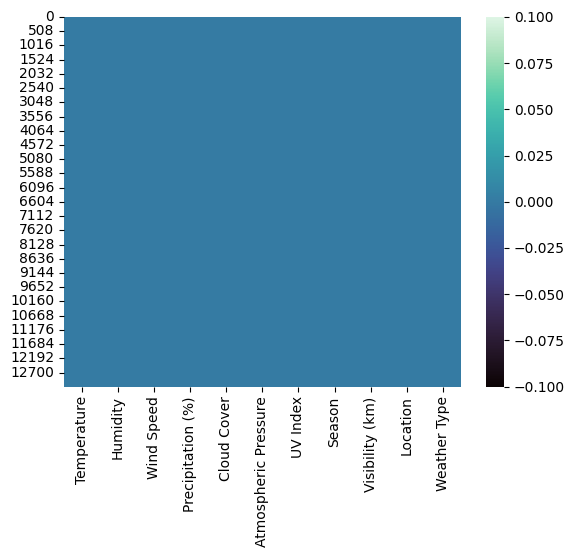

In [4]:
## Plot Heatmap to check for missing values

sns.heatmap(df.isna(), cmap = 'mako')

In [5]:
## Total count for outliers 

df.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [6]:
## Check For duplicates
df.duplicated().sum()

0

#### So The Data Has no Duplicates and Data Has no Missing values Now We can proceed to Data Outlier Removal

# Outlier Removal

In [7]:
## Function To return index of outlier data

def outlier_idx_finder(df,col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3 - q1
    
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    
    ls = df.index[(df[col] < lower) | (df[col] > upper)]
    return ls

outlier_idx = []
num_cols = list(df.select_dtypes(include = ['int', 'float']).columns)

for i in num_cols: 
    
    outlier_idx.extend(outlier_idx_finder(df,i))
    
outlier_list = set(outlier_idx)

# len(outlier_idx)

#### Over 12 Percent Of data is outlier. So we will have to perform imputation based on median Value

In [8]:
from sklearn.impute import KNNImputer


def imputer_Outlier(df):
    
    
    for col in num_cols: 
        
        idx = outlier_idx_finder(df, col)
        outlier_idx.extend(idx)
        df.loc[idx, col] = np.nan
    knn = KNNImputer(n_neighbors= 5)
    df[num_cols] = knn.fit_transform(df[num_cols])
    
    return df
    
df_new = df.copy()
df_new = imputer_Outlier(df_new)

In [9]:
df_new

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73.0,9.5,82.0,partly cloudy,1010.82,2.0,Winter,3.5,inland,Rainy
1,39.0,96.0,8.5,71.0,partly cloudy,1011.43,7.0,Spring,10.0,inland,Cloudy
2,30.0,64.0,7.0,16.0,clear,1018.72,5.0,Spring,5.5,mountain,Sunny
3,38.0,83.0,1.5,82.0,clear,1026.25,7.0,Spring,1.0,coastal,Sunny
4,27.0,74.0,17.0,66.0,overcast,990.67,1.0,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74.0,14.5,71.0,overcast,1003.15,1.0,Summer,1.0,mountain,Rainy
13196,-1.0,76.0,3.5,23.0,cloudy,1003.48,1.0,Winter,6.0,coastal,Snowy
13197,30.0,77.0,5.5,28.0,overcast,1012.69,3.0,Autumn,9.0,coastal,Cloudy
13198,3.0,76.0,10.0,94.0,overcast,984.27,0.0,Winter,2.0,inland,Snowy


# EDA

In [10]:
import matplotlib.pyplot as plt

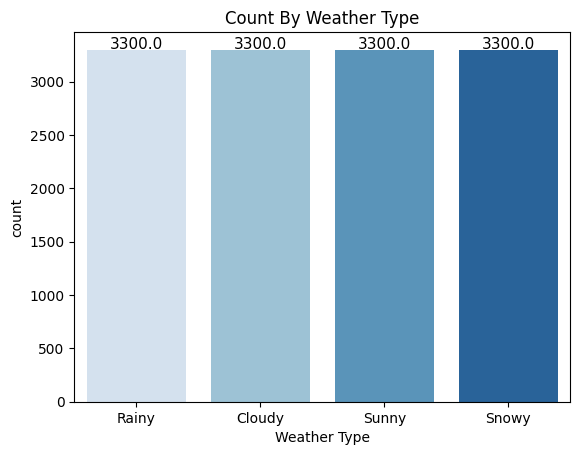

In [11]:
ax = sns.countplot(data = df_new, x = 'Weather Type', palette = 'Blues')
plt.title('Count By Weather Type')
for p in ax.patches:
    ax.annotate(
        f'\n{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                        textcoords='offset points'    
        )

#### ⭐ Distribution of Various Numerical cols

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

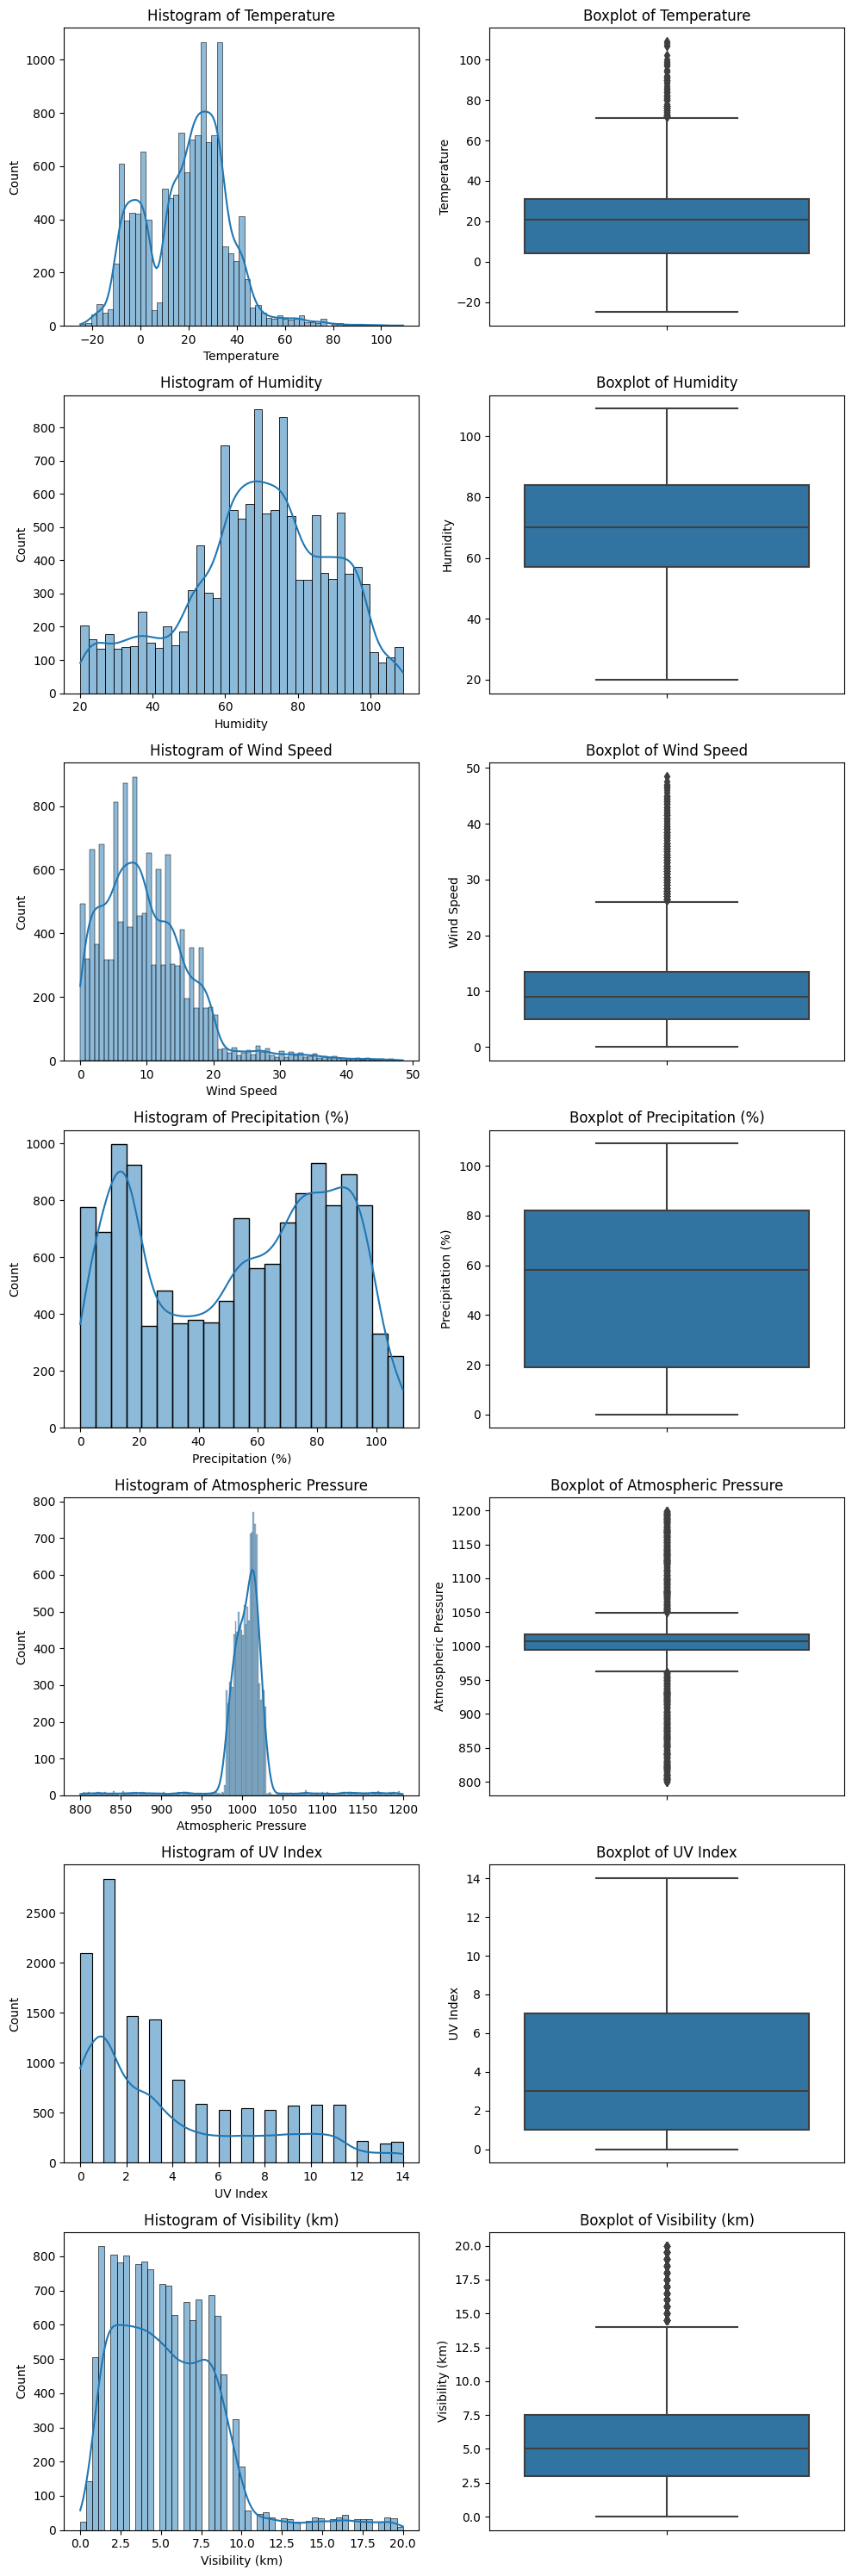

In [12]:
n_rows = 7
n_cols = 2
fig, axes = plt.subplots(nrows = n_rows, ncols = n_cols, figsize = (10,30))
for i, col  in enumerate(num_cols):
    # Histogram plot
    sns.histplot(df[col], ax=axes[i,0], kde=True)
    axes[i,0].set_title(f'Histogram of {col}')

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot of {col}')
    
plt.tight_layout()

#### ⭐ Average Value for different Factors At Different Location

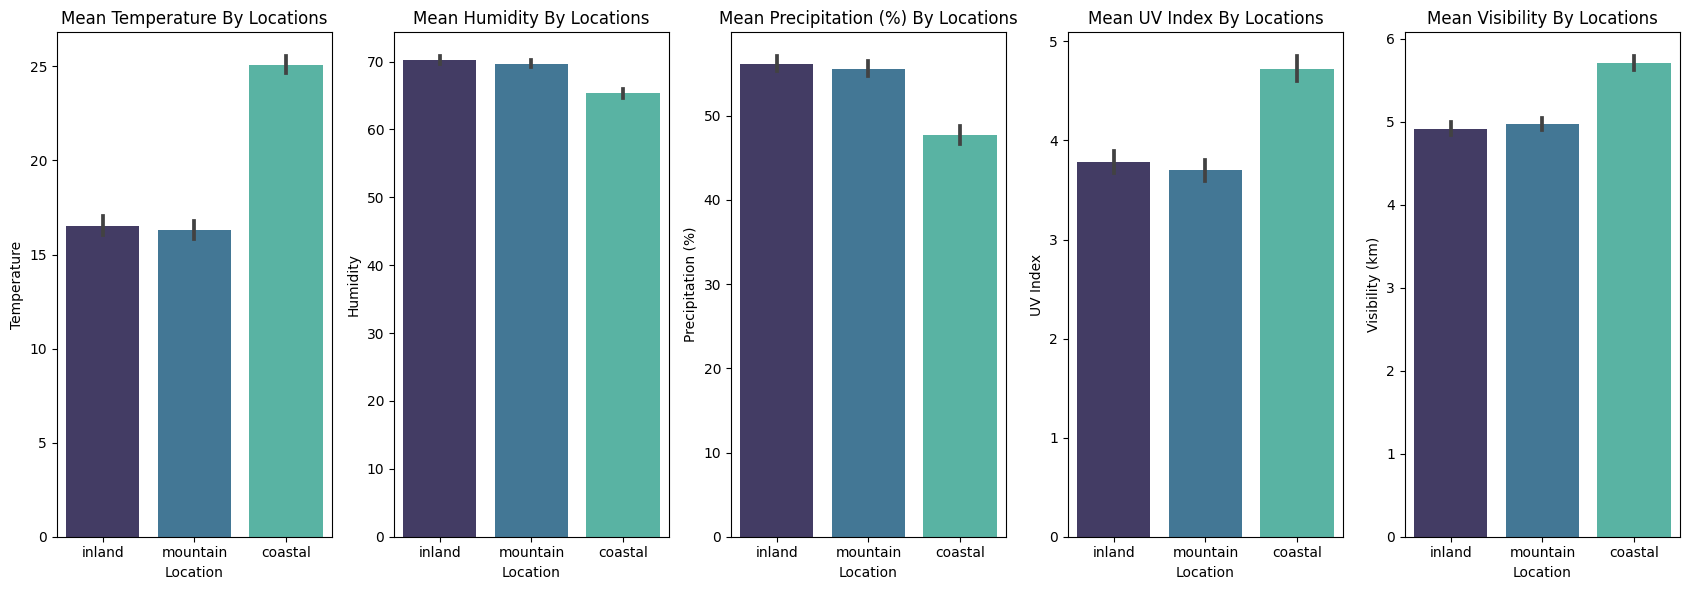

In [13]:
plt.figure(figsize = (17,6))
plt.subplot(1,5,1)
sns.barplot(data = df_new, x= 'Location',y = 'Temperature',palette = 'mako')
plt.title('Mean Temperature By Locations')

plt.subplot(1,5,2)
sns.barplot(data = df_new, x= 'Location',y = 'Humidity',palette = 'mako')
plt.title('Mean Humidity By Locations')


plt.subplot(1,5,3)
sns.barplot(data = df_new, x= 'Location',y = 'Precipitation (%)',palette = 'mako')
plt.title('Mean Precipitation (%) By Locations')

plt.subplot(1,5,4)
sns.barplot(data = df_new, x= 'Location',y = 'UV Index',palette = 'mako')
plt.title('Mean UV Index By Locations')


plt.subplot(1,5,5)
sns.barplot(data = df_new, x= 'Location',y = 'Visibility (km)',palette = 'mako')
plt.title('Mean Visibility By Locations')

plt.tight_layout()

Text(0.5, 1.0, 'Cloud Cover At By Wind Speeds (Km)')

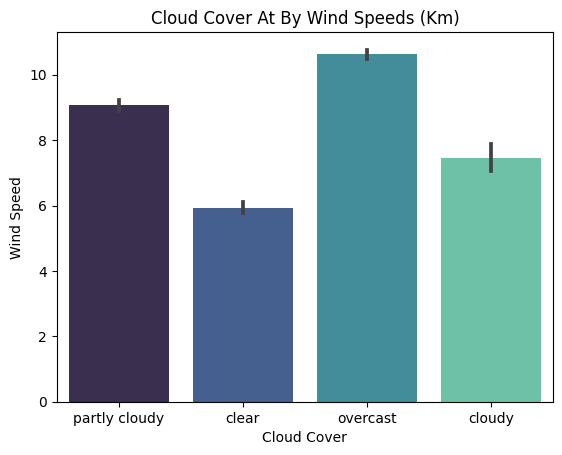

In [14]:
sns.barplot(data = df_new, x = 'Cloud Cover', y = 'Wind Speed',palette = 'mako')
plt.title('Cloud Cover At By Wind Speeds (Km)')

#### ⭐⭐ Coastal Areas Have higher chance of Rain and unlikely events of Snowfall. Whereas Mountain Location are more likely to Snow than other locations

Text(0.5, 1.0, 'Location Count By Weather Type')

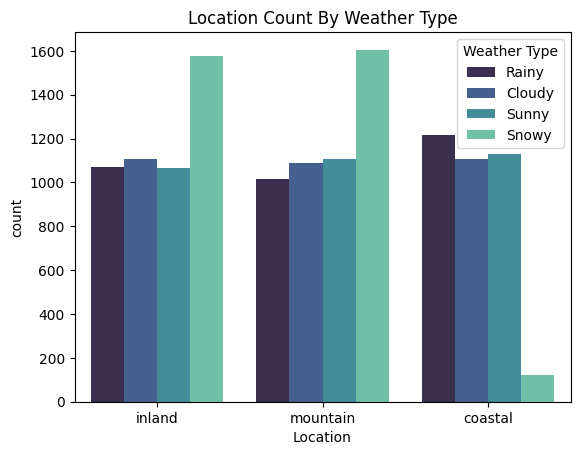

In [15]:
sns.countplot(data= df, x = 'Location',hue = 'Weather Type', palette = 'mako')
plt.title('Location Count By Weather Type')

#### ⭐⭐ Rainy And cloudy days have almost similar temperatures whereas snowy days have below zero temperatures along with       scorching heat of over 32 C on average

Text(0.5, 1.0, 'Average Temperature at different weathers')

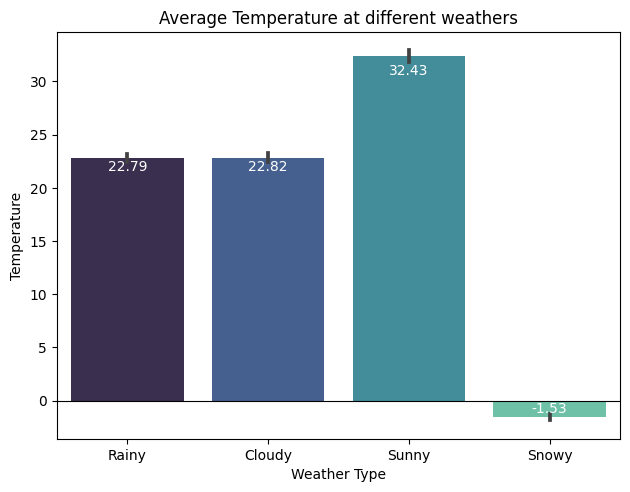

In [16]:
ax = sns.barplot(data = df, x = 'Weather Type', y = 'Temperature',estimator = 'mean',palette = 'mako')
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{np.round(height,2)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, - (height/2)),  # 3 points vertical offset
                textcoords='offset points',
                ha='center', va='bottom',color = 'white')
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()

plt.title('Average Temperature at different weathers')

# Model Selection

In [17]:
cat_cols = list(df_new.select_dtypes(include = ['O']).columns)
cat_cols.remove('Weather Type')

In [18]:
df_encoded = pd.get_dummies(df_new, columns = cat_cols, drop_first = True)

In [19]:
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [20]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [21]:
x_train, x_test, y_train, y_test = train_test_split(df_encoded.drop(columns ='Weather Type'), df_encoded['Weather Type'], test_size = 0.25, shuffle = True)

In [22]:
models = {
    'Random Forest' : RandomForestClassifier(),
    'Light GBM' : LGBMClassifier(),
    'Gradient Boost' : GradientBoostingClassifier()
}

In [23]:
for model in models:
    m = models[model]
    m.fit(x_train, y_train)
    
    y_train_pred = m.predict(x_train)
    y_test_pred = m.predict(x_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    f1_train = f1_score(y_train, y_train_pred, average = 'weighted')
    f1_test = f1_score(y_test, y_test_pred, average = 'weighted')
    
    print('-' * 40)
    print(f'<---Train Data Report On {model}--->')
    print(f'- Train Accuracy of {model} : {train_acc}')
    print(f'-F1 Score Of the {model} : {f1_train}')
    print('\n\n')
    
    print(f'<---Test Data Report On {model}--->')
    print(f'- Test Accuracy of {model} : {test_acc}')
    print(f'-F1 Score Of the {model} : {f1_test}')
    print('-' * 40)

    

----------------------------------------
<---Train Data Report On Random Forest--->
- Train Accuracy of Random Forest : 1.0
-F1 Score Of the Random Forest : 1.0



<---Test Data Report On Random Forest--->
- Test Accuracy of Random Forest : 0.9024242424242425
-F1 Score Of the Random Forest : 0.9025780462898033
----------------------------------------
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 766
[LightGBM] [Info] Number of data points in the train set: 9900, number of used features: 15
[LightGBM] [Info] Start training from score -1.383873
[LightGBM] [Info] Start training from score -1.399717
[LightGBM] [Info] Start training from score -1.389127
[LightGBM] [Info] Start training from score -1.372650


# Model HyperParameter Tuning

In [24]:
from hyperopt import hp, fmin, STATUS_OK, Trials, space_eval, tpe

In [25]:
light_params = {
    'n_estimators' :[200,400,600,800,1000,1200],
    'learning_rate' : [0.03,0.3,0.1,0.01,0.5,0.05],
    'bagging_fraction' : [0.5,0.7,1],
    'feature_fraction': [0.4,0.5,0.7,0.9,1],
    'max_depth' : [1,2,4,5,6,7,8,9,10,11,12,13,14,15],
    'lambda_l1' : [x for x in range(1,101,5)],
    'lambda_l2' : [x for x in range(1,101,5)],
    'verbose' : [-1]
}

forest_params = {
    'n_estimators' :[200,400,600,800,1000,1200],
    'max_features' : ['auto','sqrt','log2'],
    'max_depth' : [1,2,4,5,6,7,8,9,10,11,12,13,14,15],
    'min_samples_leaf': [1,2,4,6,8,10,12,14],
    'min_samples_split': [2,4,6,8,10,12,14],
    'bootstrap' : [True],
    'oob_score' : [True]
}


In [26]:
model_params_cv = [
    ('RandomForest', RandomForestClassifier(),forest_params),
    ('LightBoost', LGBMClassifier(), light_params)
]

In [27]:
model_params = {}

In [28]:
import warnings
warnings.simplefilter('ignore')

In [29]:
## Automatically train our models by usign model_params dict and Random Search CV
for name, model, params in model_params_cv:

    cv = RandomizedSearchCV(estimator = model, param_distributions = params, cv = 3, n_iter = 20, n_jobs = -1, scoring = 'accuracy',verbose = 1)
    cv.fit(x_train, y_train)
    model_params[name] = cv.best_params_


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [30]:
model_params

{'RandomForest': {'oob_score': True,
  'n_estimators': 800,
  'min_samples_split': 6,
  'min_samples_leaf': 4,
  'max_features': 'sqrt',
  'max_depth': 11,
  'bootstrap': True},
 'LightBoost': {'verbose': -1,
  'n_estimators': 200,
  'max_depth': 5,
  'learning_rate': 0.1,
  'lambda_l2': 66,
  'lambda_l1': 6,
  'feature_fraction': 0.9,
  'bagging_fraction': 0.7}}

In [31]:
forest = RandomForestClassifier(n_estimators = 1200, min_samples_split = 12, min_samples_leaf = 1, max_features = 'auto', max_depth = 15, bootstrap = True)
lightBoost = LGBMClassifier(verbose = -1, n_estimators = 800, max_depth = 5, learning_rate = 0.03, lambda_l2 =6, lambda_l1 = 1, feature_fraction = 0.4, bagging_fraction = 1)

In [32]:
## Create A dict for the final models So that it's much easier to train models 

final_models = {}
final_models['Random Forest'] = forest
final_models['Light GBM'] = lightBoost

## Create a dict to store accuracy score of our final models

results = {}

for model in final_models:
    final_models[model].fit(x_train,y_train)
    y_predicted = final_models[model].predict(x_test)
    score = accuracy_score(y_test, y_predicted)
    results[model]  = score

In [33]:
results

{'Random Forest': 0.9045454545454545, 'Light GBM': 0.9045454545454545}